# Problem Statement
Using the relevant machine learning model implement the given data

In [1]:
#load all the libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
#load the data
data = pd.read_csv('diabetes1.csv')

In [3]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Domain analsyis

Take the linear regression file as a reference and write the domian analysis for this data

# Basic checks

In [4]:
data.shape

(768, 9)

 Here the data has 768 rows and 9 columns

In [5]:
data.head()
#head is showing the first 5 rows of info

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [7]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [8]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [9]:
# since the target value is descrete , analyse the same
data['Outcome'].unique()

array([1, 0])

In [10]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
#by analsying the target column ,we can get to know whether the data is balanced or not
# 0 500 rows info, 1 268 rows of info

# that is more info is there w.r.t to ppl having no diabetes
# less info w,rt to having dia

# if this is the case, we say data is not balanced

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
# Glucose	BloodPressure	SkinThickness	Insulin	BMI
#For these columns the mini value is 0
# it can never go 0 for a person who is alive
# this concludes there are corrupted values in the data
# we should handle them , during cleaing the data, replace 0 by median of the column

# EDA

Univariate analsyis - analyse the single column
              
              - cat / descrete - countplot
              - continuous -> histogram / box
              
Bivarite - 2 col analysis

              - num vs num  -> scatter, line, rel
              - num vs cat   -> count(hue), bar, box (hue)

Multivariate
             
             - Pairplot

In [15]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

<Axes: xlabel='Outcome', ylabel='count'>

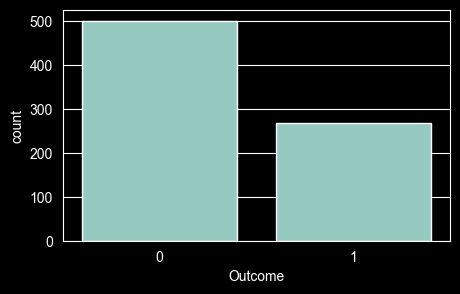

In [17]:
# target column
# count plot
plt.figure(figsize=(5,3))
sns.countplot(x=data['Outcome'])

Insight: 0 class occurances are more

In [18]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
data.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [20]:
data['Pregnancies'].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14])

<Axes: xlabel='Pregnancies', ylabel='count'>

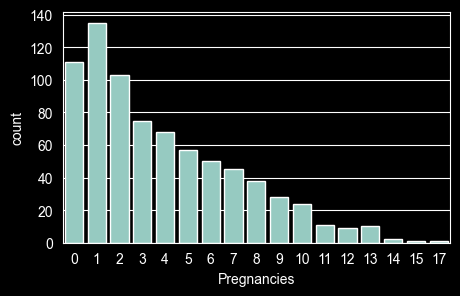

In [21]:
plt.figure(figsize=(5,3))
sns.countplot(x=data['Pregnancies'])

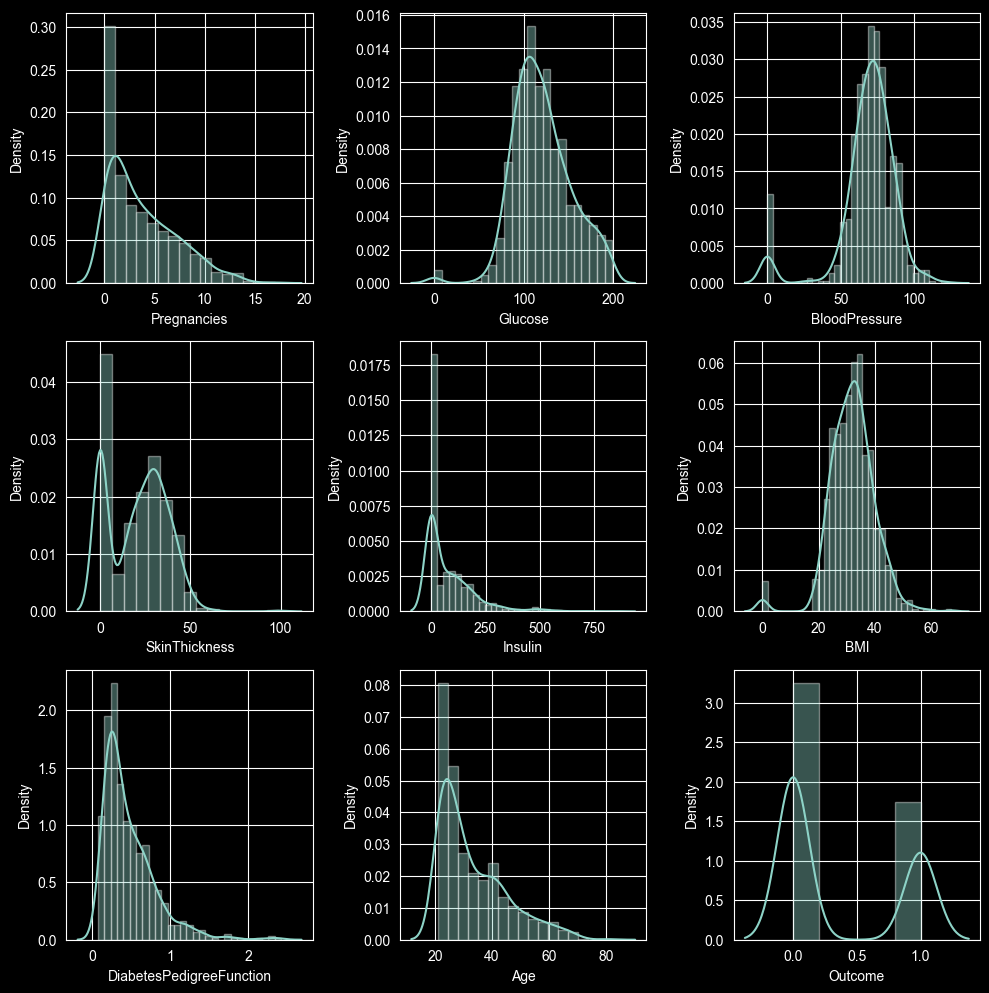

In [22]:
#SUBPLOT
plt.figure(figsize=(10,10))
plot = 1

for i in data:
    if plot<=9:
        ax = plt.subplot(3,3,plot)
        sns.distplot(x=data[i])
        plt.xlabel(i)
    plot+=1
plt.tight_layout()
        

In [24]:
#Insights

# Bivariate

<Axes: xlabel='Pregnancies', ylabel='count'>

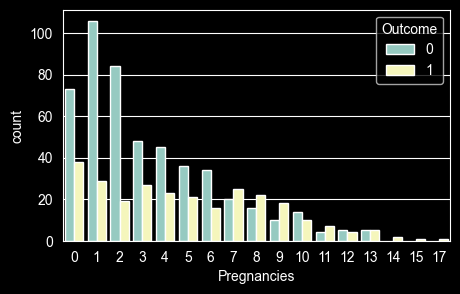

In [23]:
# analyse all the input varibales vs target
plt.figure(figsize=(5,3))
sns.countplot(x=data['Pregnancies'],hue=data['Outcome'])

In [24]:
#insight : as the number of pregnancies increases the chances of getting diabetes is also increasing

<Axes: xlabel='Glucose', ylabel='Count'>

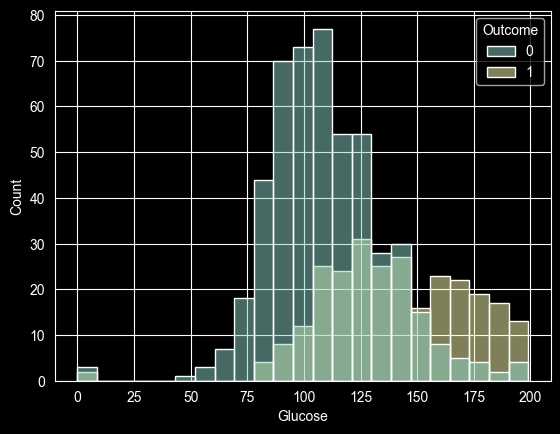

In [25]:
sns.histplot(x=data['Glucose'],hue=data['Outcome'])

In [26]:
#insight :

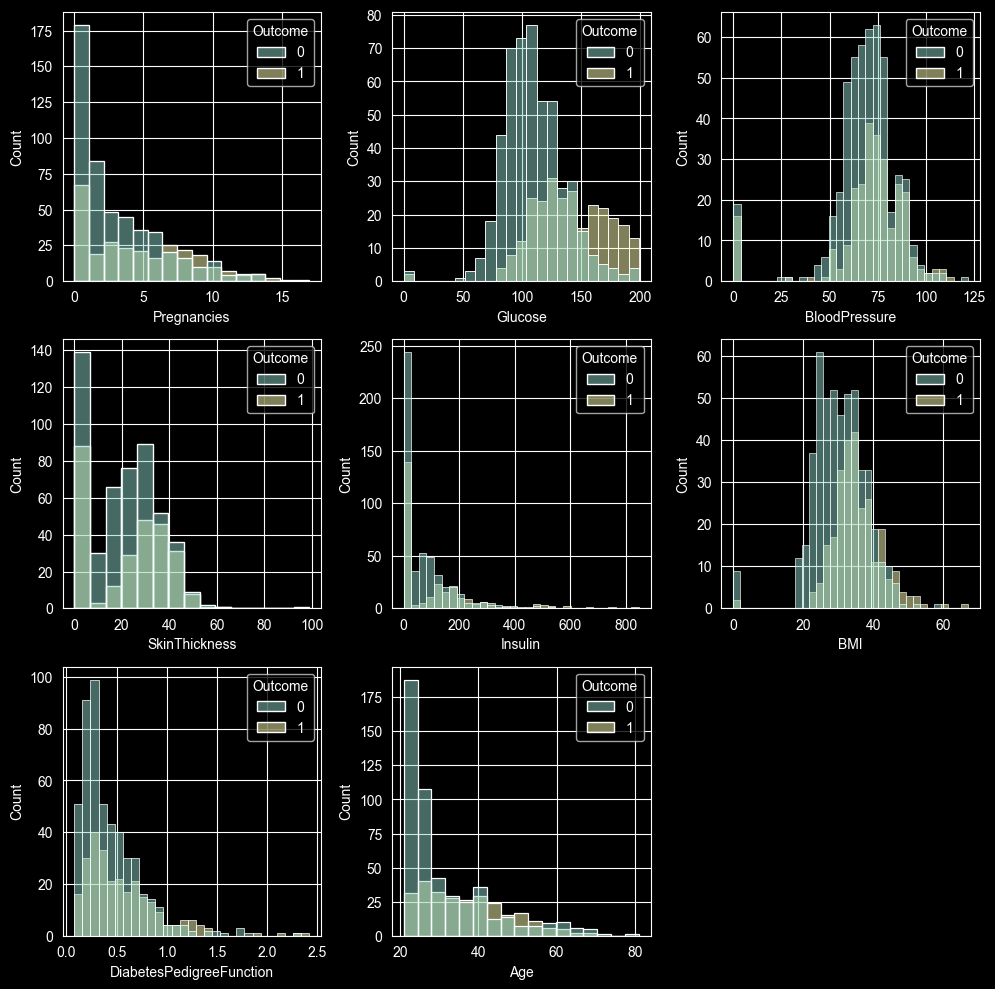

In [27]:
#SUBPLOT - input vs target
plt.figure(figsize=(10,10))
plotnumber = 1

for i in data.drop('Outcome',axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.histplot(x=data[i], hue=data['Outcome'])
        plt.xlabel(i,fontsize=10)
    plotnumber +=1
plt.tight_layout()
    
        

In [32]:
#insight for all the graphs

# Pair plot

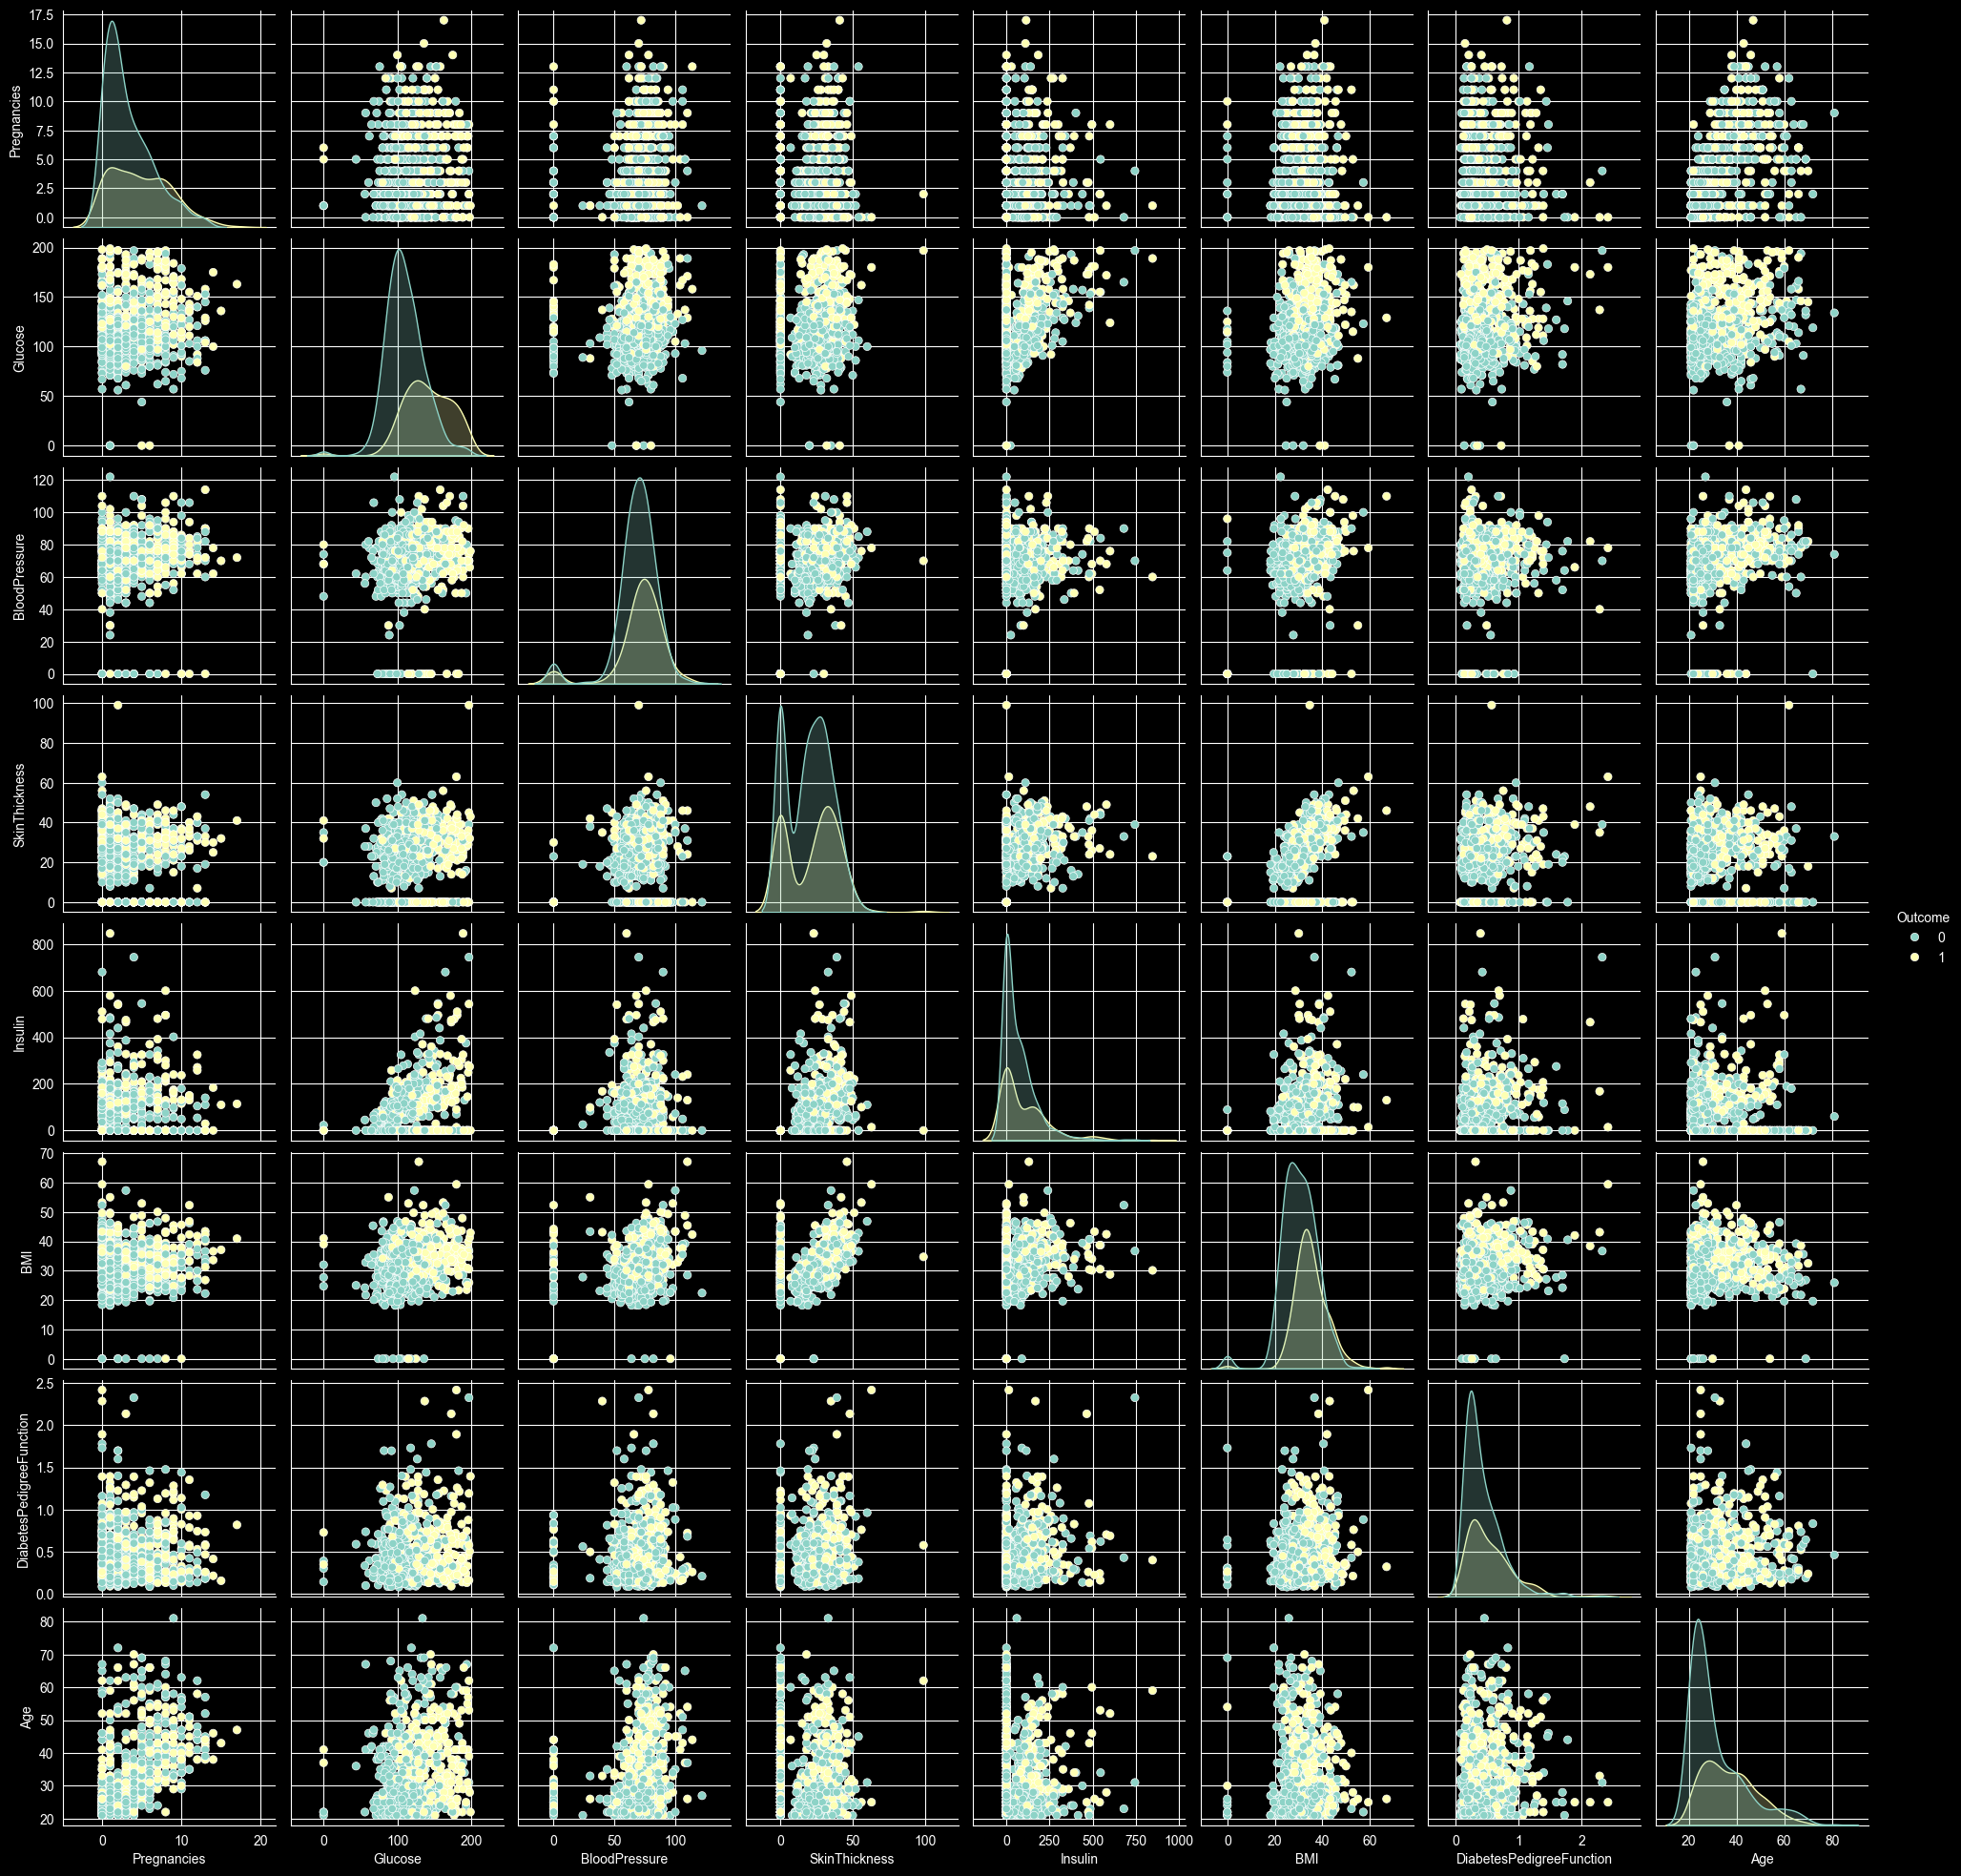

In [28]:
sns.pairplot(data,hue='Outcome')
#sns.paiplot(data , hue='Outcome')

# Pre processing

In [29]:
#null values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [30]:
data.duplicated().sum()

np.int64(0)

In [36]:
# Glucose	BloodPressure	SkinThickness	Insulin	BMI
#For these columns the mini value is 0
# it can never go 0 for a person who is alive
# this concludes there are corrupted values in the data
# we should handle them , during cleaing the data, replace 0 by median of the column

In [31]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [32]:
data.loc[data['Glucose']==0,'Glucose']  = data['Glucose'].median()

In [33]:
data['BloodPressure'].replace(0,data['BloodPressure'].median(),inplace=True)

0      72
1      66
2      64
3      66
4      40
       ..
763    76
764    70
765    72
766    60
767    70
Name: BloodPressure, Length: 768, dtype: int64

In [34]:

data['SkinThickness'].replace(0, data['SkinThickness'].median(),inplace = True)
data['Insulin'].replace(0, data['Insulin'].median(),inplace = True)
data['BMI'].replace(0, data['BMI'].median(),inplace = True)

0      33.6
1      26.6
2      23.3
3      28.1
4      43.1
       ... 
763    32.9
764    36.8
765    26.2
766    30.1
767    30.4
Name: BMI, Length: 768, dtype: float64

In [35]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,30.438286,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [41]:
#outlier detection
#handling outlier is very important for the logistic model
# plot a box plot and then decide whether a column has a outlier or not


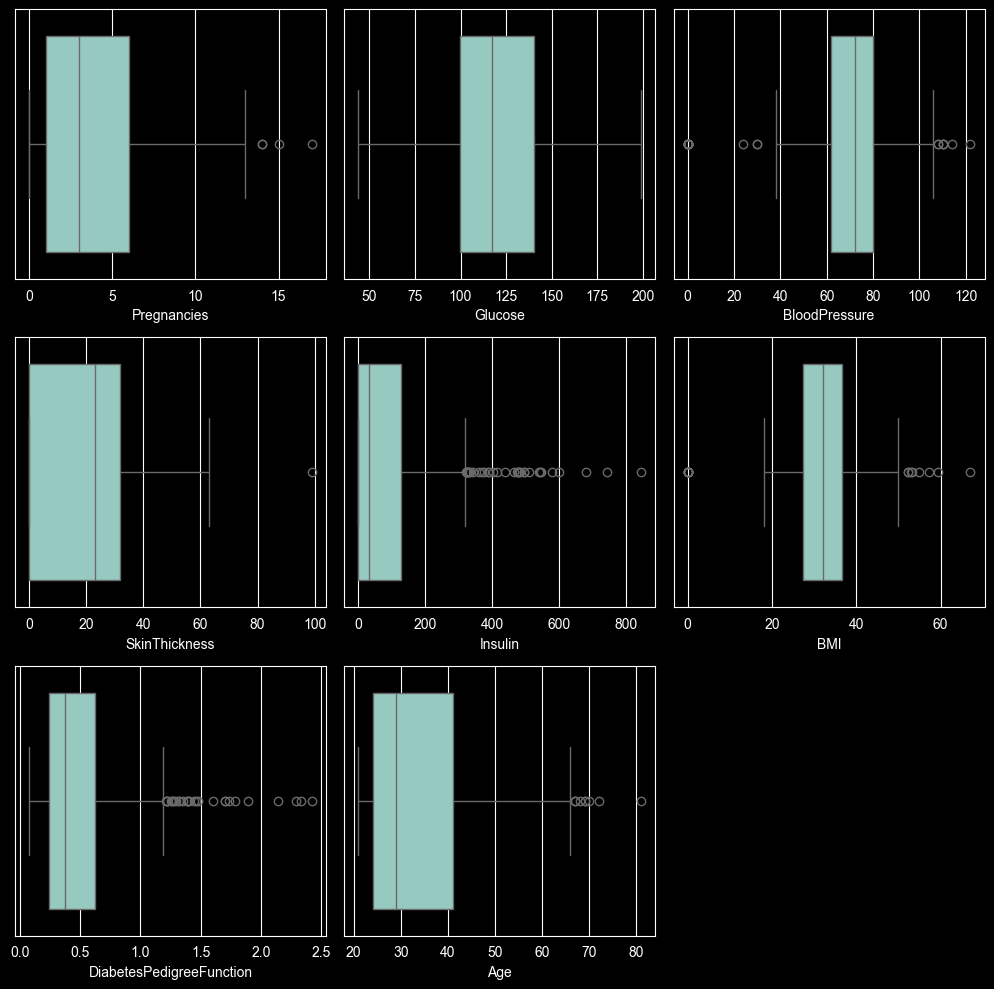

In [36]:
#SUBPLOT
plt.figure(figsize=(10,10))
plotnumber = 1

for i in data.drop('Outcome',axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.boxplot(x=data[i])
        plt.xlabel(i,fontsize=10)
    plotnumber +=1
plt.tight_layout()
    
        

In [37]:
# we can see all the column has outliers
# we need to handle them
# for us to handle , we need to get to know the distribution
#SUBPLOT
plt.figure(figsize=(10,10))
plotnumber = 1

for i in data.drop(columns=['Glucose','Outcome'],axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.distplot(x=data[i])
        plt.xlabel(i,fontsize=10)
    plotnumber +=1
plt.tight_layout()
    
        

ValueError: Cannot specify both 'axis' and 'index'/'columns'

<Figure size 1000x1000 with 0 Axes>

In [45]:
# all the above columns are giving us the skewed distribution, hence we are handling outliers by
# IQR method
# task

# Feature selection

In [38]:
#drop the irrlevant columns

<Axes: >

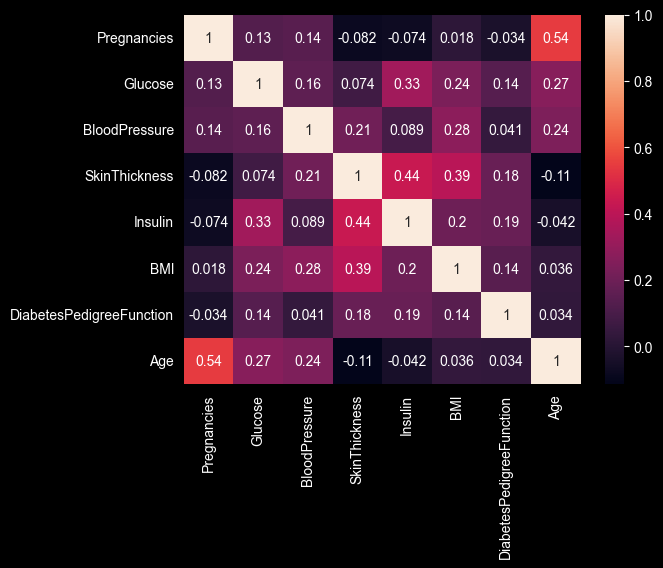

In [39]:
# co relation of data
sns.heatmap(data.drop('Outcome',axis=1).corr(),annot=True)

In [28]:
# no two input columns show corelation higher 80% so we are selecting all the columns

# Model Building

In [54]:
x = data.drop('Outcome',axis=1)
y = data[['Outcome']]
y.value_counts()

Outcome
0          500
1          268
Name: count, dtype: int64

In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train , y_test = train_test_split(x,y,test_size=0.30,random_state=2)

In [43]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = pd.DataFrame(sc.fit_transform(x_train),columns=x_train.columns)
x_test = pd.DataFrame(sc.transform(x_test),columns=x_test.columns)

In [44]:
#apply the logistic Regression
#import the algo
from sklearn.linear_model import LogisticRegression

# init
model = LogisticRegression()

# train the model
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [45]:
# test the model with new records
# x_test
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0])

# Evaluate the model


In [48]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score,classification_report


In [49]:
confusion_matrix(y_test,y_pred)

array([[137,  18],
       [ 39,  37]])

In [50]:
accuracy_score(y_test,y_pred)

0.7532467532467533

In [52]:
precision_score(y_test,y_pred)

0.6727272727272727

In [53]:
f1_score(y_test,y_pred)

0.5648854961832062

In [48]:
recall_score(y_test,y_pred)

0.4342105263157895

In [49]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.89      0.82       155
           1       0.66      0.43      0.52        76

    accuracy                           0.74       231
   macro avg       0.71      0.66      0.67       231
weighted avg       0.73      0.74      0.72       231



In [53]:
from sklearn.metrics import roc_curve, auc
false_positive_rate, true_positive_rate , thresholds = roc_curve(y_test,y_pred)
auc_score = auc(false_positive_rate, true_positive_rate)
auc_score

0.6622665534804754

In [58]:
# the range is from 0 to 1
# since 0.66 is near to 1 , we can say the model is pretty good
false_positive_rate, true_positive_rate , thresholds = roc_curve(y_test,y_pred)
false_positive_rate


array([0.        , 0.10967742, 1.        ])

In [57]:
true_positive_rate

array([0.        , 0.43421053, 1.        ])

In [59]:
thresholds

array([inf,  1.,  0.])

In [ ]:
#inf - infinity   -> predicts negative

# 1 maximum probability - > this threshold says if the predicted probability is
                         # equal to or greater than 1 -> classify it as positive class

# 0 minimun probability  - > this threshold says if the predicted probability is
                         # low or even 0 - > classify as positive class